# TSAC 2025/2026: Data Classification Challenge
## Home Appliance Power Signature Recognition

### 1. Introduction & Problem Statement
The objective of this project is to build a robust classification model capable of identifying 10 distinct categories of home appliances:
- **0:** Mobile Phone (charger)
- **1:** Coffee Machine
- **2:** Computer Station
- **3:** Fridge/Freezer
- **4:** Hi-Fi / CD player
- **5:** CFL lamp
- **6:** Laptop (charger)
- **7:** Microwave Oven
- **8:** Printers
- **9:** Televisions (LCD or LED)

by the appliance's power signature.

### 2. Dataset Overview

In [1]:
import pandas as pd
df_train = pd.read_csv('../data/train.csv', header=None)

df_train.rename(columns={0: 'label'}, inplace=True)

df_train.head(5)

,label,1,2,3,4,5,6,7,8,9,...,1451,1452,1453,1454,1455,1456,1457,1458,1459,1460
0,9,-0.584754,-0.584754,1.730991,-0.584754,-0.584754,-0.584754,1.729917,-0.584754,-0.584754,...,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734,-0.583729,-0.578603,1.732726,-0.584734
1,9,-0.591434,-0.511104,1.726820,-0.580422,-0.591434,-0.511104,1.727921,-0.580422,-0.591434,...,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731,-0.580731,-0.580731,1.727396,-0.580731
2,9,-0.577945,-0.577945,1.730793,-0.577945,-0.578946,-0.564882,1.731094,-0.577829,-0.580956,...,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751,-0.580956,-0.549798,1.734727,-0.577751
3,9,-0.588925,-0.538088,1.735718,-0.588716,-0.589962,-0.523551,1.735619,-0.588646,-0.588925,...,1.743664,-0.588876,-0.586852,-0.576483,1.743664,-0.588876,-0.586852,-0.576483,1.743664,-0.588876
4,9,-0.596633,-0.532188,1.718067,-0.592117,-0.596633,-0.532188,1.715241,-0.592117,-0.595605,...,1.743258,-0.592403,-0.591524,-0.575158,1.743258,-0.592403,-0.591524,-0.575158,1.743258,-0.592403


In [2]:
df_train.shape

(100, 1461)

Class Distribution:
  Class 0:     10  (10.00%)
  Class 1:     10  (10.00%)
  Class 2:     10  (10.00%)
  Class 3:     10  (10.00%)
  Class 4:     10  (10.00%)
  Class 5:     10  (10.00%)
  Class 6:     10  (10.00%)
  Class 7:     10  (10.00%)
  Class 8:     10  (10.00%)
  Class 9:     10  (10.00%)

Total samples: 100
Mean per class: 10.0
Min: 10, Max: 10, Std: 0.0


<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Count'>

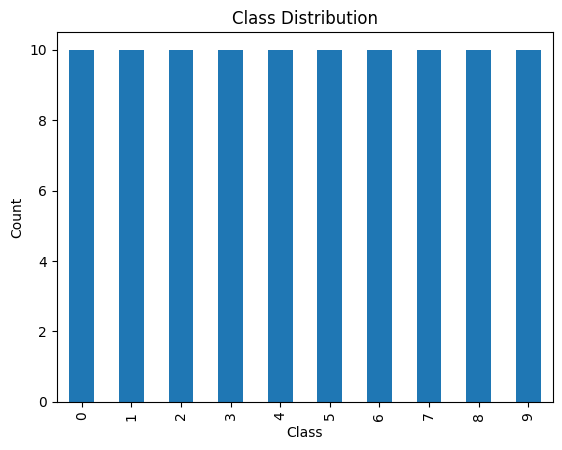

In [3]:
# Count and proportion
counts = df_train['label'].value_counts().sort_index()
props = df_train['label'].value_counts(normalize=True).sort_index()

print('Class Distribution:')
for cls in range(10):
    print(f'  Class {cls}: {counts.get(cls, 0):6d}  ({props.get(cls, 0):.2%})')
print(f'\nTotal samples: {len(df_train)}')
print(f'Mean per class: {len(df_train) / 10:.1f}')
print(f'Min: {counts.min()}, Max: {counts.max()}, Std: {counts.std():.1f}')

counts.plot(kind='bar', title='Class Distribution', xlabel='Class', ylabel='Count')

In [4]:
# Select one instance per class (first occurrence)
sample_per_class = df_train.groupby('label').first().reset_index()

# Feature columns are 1 through 1460
feature_cols = list(range(1, 1461))

# Compute summary stats for each selected row's feature values
stats = sample_per_class[feature_cols].agg(['mean', 'std', 'min', 'max', 'median'], axis=1)
stats.index = sample_per_class['label']
stats.columns = ['Mean', 'Std', 'Min', 'Max', 'Median']

print('Per-instance feature statistics (one row per class):\n')
print(stats.round(4).to_string())
print(f'\nOverall feature mean across selected instances: {sample_per_class[feature_cols].values.mean():.6f}')
print(f'Overall feature std  across selected instances: {sample_per_class[feature_cols].values.std():.6f}')

Per-instance feature statistics (one row per class):

       Mean     Std     Min      Max  Median
label                                       
0      -0.0  1.0003 -0.9588   1.3573 -0.8577
1      -0.0  1.0003 -1.2015   1.6898 -0.4509
2       0.0  1.0003 -0.8560   1.6878 -0.4948
3       0.0  1.0003 -0.5547  10.8138 -0.4723
4      -0.0  1.0003 -0.9330   1.6753 -0.5876
5       0.0  1.0003 -0.6359   1.7500 -0.5904
6      -0.0  1.0003 -0.6059   1.7563 -0.5615
7      -0.0  1.0003 -1.3345  10.7656 -0.6045
8      -0.0  1.0003 -0.5339   4.2421 -0.5079
9       0.0  1.0003 -0.5919   1.7480 -0.5837

Overall feature mean across selected instances: -0.000000
Overall feature std  across selected instances: 1.000000


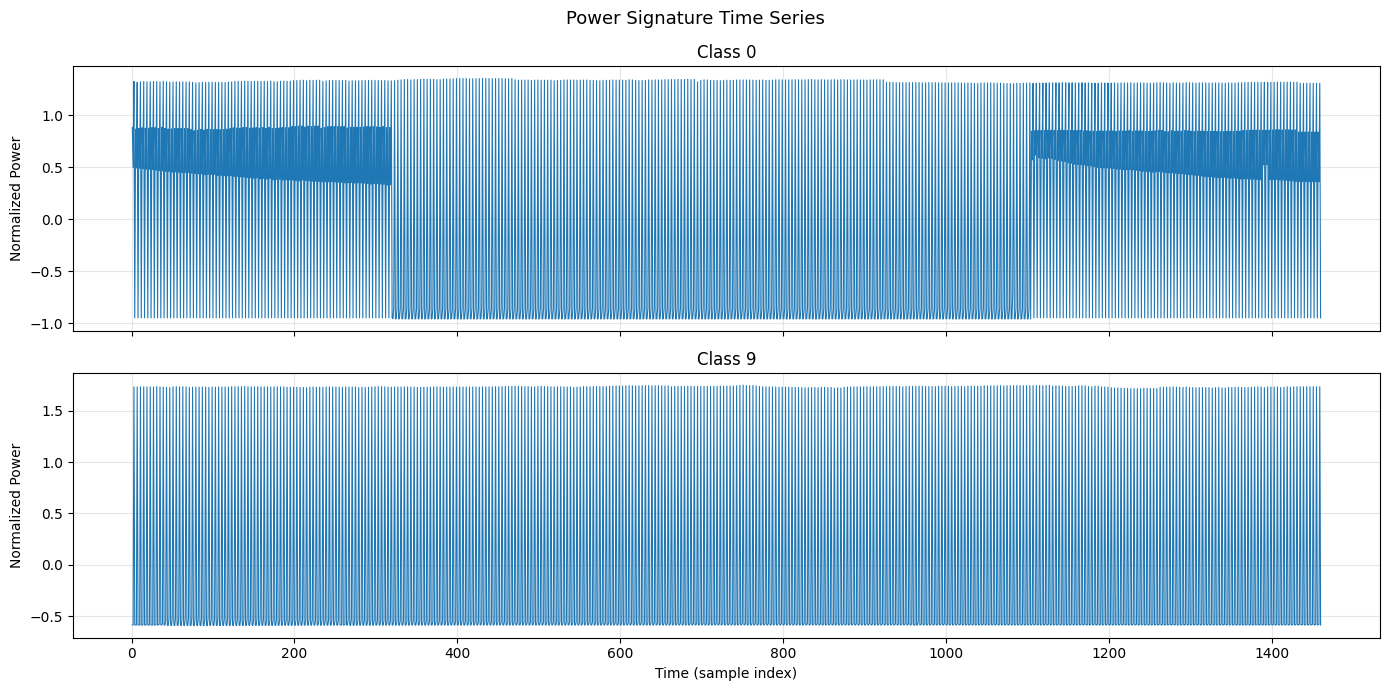

In [5]:
import matplotlib.pyplot as plt

# Pick first instance from two different classes
class_a, class_b = 0, 9
row_a = df_train[df_train['label'] == class_a].iloc[0]
row_b = df_train[df_train['label'] == class_b].iloc[0]
feature_cols = list(range(1, 1461))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(feature_cols, row_a[feature_cols].values, linewidth=0.8)
ax1.set_ylabel('Normalized Power')
ax1.set_title(f'Class {class_a}')
ax1.grid(True, alpha=0.3)
ax2.plot(feature_cols, row_b[feature_cols].values, linewidth=0.8)
ax2.set_xlabel('Time (sample index)')
ax2.set_ylabel('Normalized Power')
ax2.set_title(f'Class {class_b}')
ax2.grid(True, alpha=0.3)
fig.suptitle('Power Signature Time Series', fontsize=13)
plt.tight_layout()
plt.show()

* **Dataset Shape:** The dataset contains exactly 100 rows and 1,461 columns (1 target class label + 1,460 sequential time-step features).
* **Perfect Class Balance:** The dataset is perfectly balanced. There are exactly 10 instances for each of the 10 appliance categories (10% distribution per class).
* **Standardization Confirmed:** A statistical check of the feature columns confirms a strict mean of `0.0` and a standard deviation of `1.0` across the instances. This proves the time-series data has already been completely Z-score normalized.
* **Visual Signature Analysis:** Despite the standardization stripping away absolute wattage, plotting random samples reveals highly distinct temporal "shapes" for different appliances:

## 3. Modeling

### 3.1 First Approach: Feature Extraction & Random Forest

Given the unique characteristics of our dataset discovered during the Data Overview, a simple approach of extracting meaningfull features from the time series and using classical ML models seems highly advantageous for our specific dataset for three key reasons:

1. **The Dimensionality Problem:** We have 1,460 time-step features but only 100 training instances.Using complex models would almost certainly result in severe overfitting on the training set. By condensing the 1,460 steps into a handful of summary statistics, we drastically reduce the dimensionality and stabilize the learning process.
2. **Capitalizing on "Shape" over Amplitude:** Because the data is Z-score normalized (mean = 0, std = 1), absolute power values (Watts) are completely lost. By extracting statistical features—such as the maximum peak, kurtosis (tailedness), variance, and mean-crossing rate—we force the model to classify appliances based purely on the physical *shape*, *volatility*, and *jaggedness* of their power draw.
3. **Maximum Interpretability:** Random Forests are powerful ensemble models that natively calculate **Feature Importance**. This allows us to avoid "black-box" predictions. Instead, we will be able to explicitly prove and document *which* specific signal shapes are most responsible for identifying specific appliances.

#### A. Distribution Features 
1. **Maximum (`Max`):** The highest relative peak. Identifies appliances with sudden, massive power surges (e.g., microwaves or fridge compressors).
2. **Minimum (`Min`):** The lowest relative dip in the sequence.
3. **Skewness:** Measures the asymmetry of the power draw. A highly skewed distribution indicates an appliance that spends most of its time idle but has brief, intense bursts of power.
4. **Kurtosis:** Measures the "tailedness" of the sequence. High kurtosis indicates the presence of extreme, unpredictable outlier spikes in consumption.
5. **Interquartile Range (`IQR`):** The difference between the 75th and 25th percentiles. This measures the stability of the appliance's "normal" operating bounds, actively ignoring split-second extreme spikes.

#### B. Temporal Features 
6. **Mean Absolute Change:** The average mathematical difference between consecutive time steps ($|x_t - x_{t-1}|$). This quantifies the "jaggedness" or noise of the line. A continuously processing computer will have a high mean change, whereas a steady lamp will have a low mean change.
7. **Zero-Crossing Rate:** Since our data's mean is mathematically forced to 0.0, this metric counts how many times the sequence crosses from negative (below average) to positive (above average). A fridge cycling on and off will cross zero very rarely, whereas a highly volatile appliance will cross it hundreds of times.

By transforming our dataset from `(100, 1460)` raw time steps into `(100, 7)` distinct structural features, we effectively neutralize the curse of dimensionality while retaining the core physical signature of each appliance.

In [6]:
import numpy as np
from scipy.stats import skew, kurtosis

feature_cols = list(range(1, 1461))
X_raw = df_train[feature_cols].values
p75, p25 = np.percentile(X_raw, [75, 25], axis=1)
features = {
    'max':          np.max(X_raw, axis=1),
    'min':          np.min(X_raw, axis=1),
    'skewness':     skew(X_raw, axis=1),
    'kurtosis':     kurtosis(X_raw, axis=1),
    'iqr':          p75 - p25,
    'mean_abs_chg': np.mean(np.abs(np.diff(X_raw, axis=1)), axis=1),
    'zero_cross':   np.sum(np.diff(np.signbit(X_raw), axis=1).astype(bool), axis=1),
}
df_features = pd.DataFrame(features)
df_features.insert(0, 'label', df_train['label'].values)
df_features.head(10)

,label,max,min,skewness,kurtosis,iqr,mean_abs_chg,zero_cross
0,9,1.747964,-0.591929,1.154184,-0.666973,0.622166,1.159583,730
1,9,1.745335,-0.591434,1.154224,-0.666973,0.624972,1.157709,730
2,9,1.740127,-0.580956,1.154660,-0.666677,0.597781,1.155887,730
3,9,1.746456,-0.589962,1.153912,-0.667159,0.624142,1.161135,730
4,9,1.745156,-0.596633,1.153159,-0.667817,0.622725,1.163967,730
5,9,1.769192,-0.592143,1.153878,-0.666611,0.614699,1.160686,730
6,9,1.770360,-0.588574,1.154461,-0.666003,0.591955,1.160623,730
7,9,1.751915,-0.607116,1.152315,-0.668352,0.625766,1.168457,730
8,9,1.752418,-0.589975,1.154493,-0.666629,0.615773,1.157798,730
9,9,1.742667,-0.596624,1.153296,-0.667633,0.616740,1.164214,730


In [7]:
for cls in range(10):
    subset = df_features[df_features['label'] == cls].head(10)
    print(f'--- Class {cls} ---')
    print(subset.to_string(index=False), '\n')

--- Class 0 ---
 label      max       min  skewness  kurtosis      iqr  mean_abs_chg  zero_cross
     0 1.357316 -0.958804  0.252658 -1.756154 1.958182      1.242274         729
     0 5.283505 -0.650023  1.144083 -0.311985 2.320967      1.175426         730
     0 3.651676 -0.910306  0.575734 -1.196988 2.418044      1.320322         986
     0 1.664864 -0.729164  0.896735 -0.980243 1.354249      1.242864         944
     0 1.513273 -0.886226  0.537132 -1.533640 1.800991      1.203715         730
     0 1.743227 -0.740854  1.038435 -0.812458 1.243116      1.192282         730
     0 1.701085 -0.706057  0.978135 -0.868425 1.265395      1.192299         730
     0 1.671560 -0.684002  0.930743 -0.976252 1.433993      1.172368         730
     0 2.869941 -0.880492  0.732044 -1.055614 2.400019      1.348123        1166
     0 1.729779 -0.730630  1.102370 -0.722645 1.025932      1.181605         730 

--- Class 1 ---
 label      max       min  skewness  kurtosis      iqr  mean_abs_chg  zero_

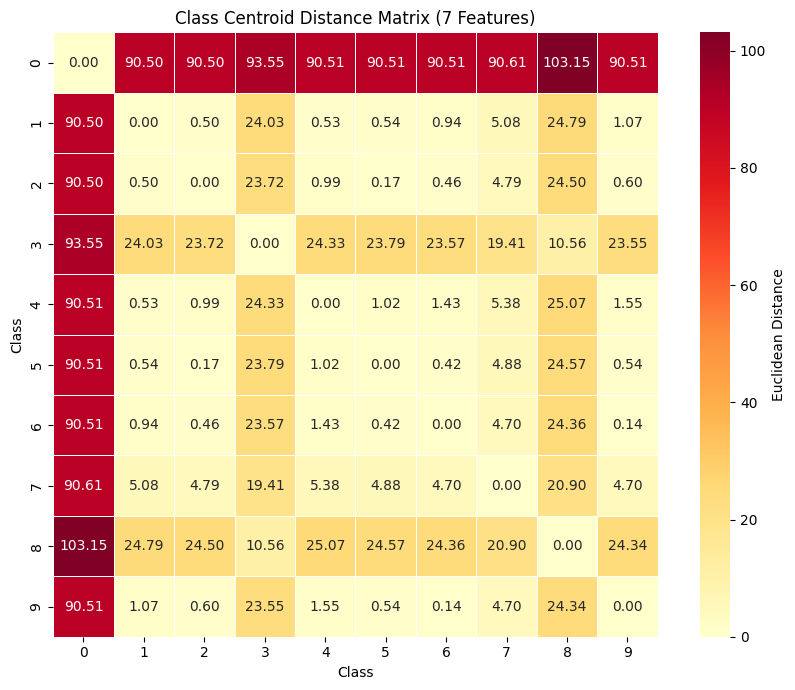

In [8]:
# Class Separability
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

feature_names = ['max', 'min', 'skewness', 'kurtosis', 'iqr', 'mean_abs_chg', 'zero_cross']

# Centroids: mean of each feature per class
centroids = df_features.groupby('label')[feature_names].mean()  # shape (10, 7)

# Euclidean distance between every pair of centroids
dist_matrix = squareform(pdist(centroids.values, metric='euclidean'))

dist_df = pd.DataFrame(dist_matrix, index=range(10), columns=range(10))

plt.figure(figsize=(9, 7))
sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd', square=True,
            linewidths=0.5, cbar_kws={'label': 'Euclidean Distance'})
            
plt.title('Class Centroid Distance Matrix (7 Features)')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

#### **Key Findings:**
- **1.** most classes (1,2,4,5,6,9) are really close together making it hard for classification
- **2.** classes (0,3,7,8) are really diffrent from other classes making it viable for an ensemble learning strategy where a simple model like random forest is good at classifying them

#### Conclusion:
**1.** this is will obviously make a bad classifier we are going to need more meaningful features 

#### Automatic Feature Extraction (tsfresh):

In [9]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute

# Melt df_train from wide to long: one row per (sample, time_step)
feature_cols = list(range(1, 1461))
df_long = df_train[feature_cols].copy()
df_long['id'] = df_train.index
df_long = df_long.melt(id_vars='id', var_name='time', value_name='value')

# Extract ALL tsfresh features
X_tsfresh = extract_features(df_long, column_id='id', column_sort='time', n_jobs=0)

# Impute NaNs (some feature calculators produce them)
X_tsfresh = impute(X_tsfresh)

# Select top features by relevance to label
y = df_train['label'].values

X_selected = select_features(X_tsfresh, y)

Feature Extraction: 100%|██████████| 100/100 [02:01<00:00,  1.22s/it]
c:\Users\Glywin\Desktop\TSAC\tsa_group_project\venv\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns ['value__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [10]:
from tsfresh.feature_selection.relevance import calculate_relevance_table

y_series = pd.Series(y, index=X_tsfresh.index)
relevance = calculate_relevance_table(X_tsfresh, y_series)
sorted_order = relevance.sort_values('p_value')['feature'].tolist()
sorted_order = [f for f in sorted_order if f in X_selected.columns]
X_selected = X_selected[sorted_order]

In [11]:
print(f'Total features extracted: {X_tsfresh.shape[1]}')
print(f'Selected features:        {X_selected.shape[1]}')
print(f'\nTop selected features:')
for f in X_selected.columns[:20]:
    print(f'  {f}')

Total features extracted: 783
Selected features:        336

Top selected features:
  value__ratio_beyond_r_sigma__r_7
  value__ratio_beyond_r_sigma__r_5
  value__number_peaks__n_3
  value__ratio_beyond_r_sigma__r_6
  value__ratio_beyond_r_sigma__r_3
  value__ratio_beyond_r_sigma__r_2.5
  value__ratio_beyond_r_sigma__r_2
  value__large_standard_deviation__r_0.2
  value__number_crossing_m__m_-1
  value__large_standard_deviation__r_0.25
  value__symmetry_looking__r_0.1
  value__large_standard_deviation__r_0.30000000000000004
  value__fft_coefficient__attr_"abs"__coeff_17
  value__fft_coefficient__attr_"abs"__coeff_10
  value__spkt_welch_density__coeff_2
  value__c3__lag_3
  value__c3__lag_1
  value__agg_linear_trend__attr_"intercept"__chunk_len_50__f_agg_"max"
  value__change_quantiles__f_agg_"var"__isabs_False__qh_0.8__ql_0.0
  value__fft_coefficient__attr_"abs"__coeff_6


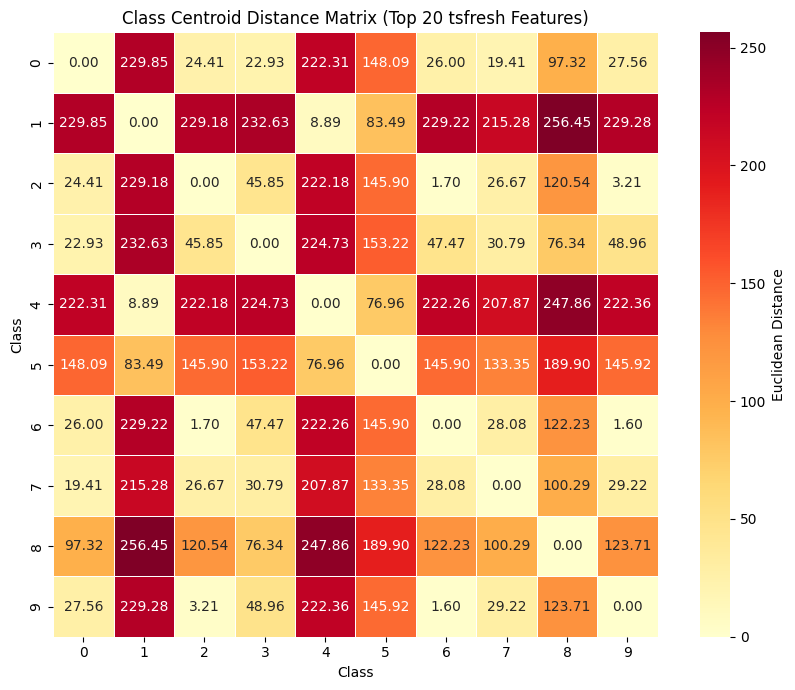

In [12]:
# Top 20 features from tsfresh selection
top20 = X_selected.columns[:20]
df_top20 = X_selected[top20].copy()
df_top20.insert(0, 'label', y)

# Centroids
centroids = df_top20.groupby('label')[top20].mean()

# Euclidean distance matrix
dist_matrix = squareform(pdist(centroids.values, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, index=range(10), columns=range(10))

plt.figure(figsize=(9, 7))
sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd', square=True,
            linewidths=0.5, cbar_kws={'label': 'Euclidean Distance'})
plt.title('Class Centroid Distance Matrix (Top 20 tsfresh Features)')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

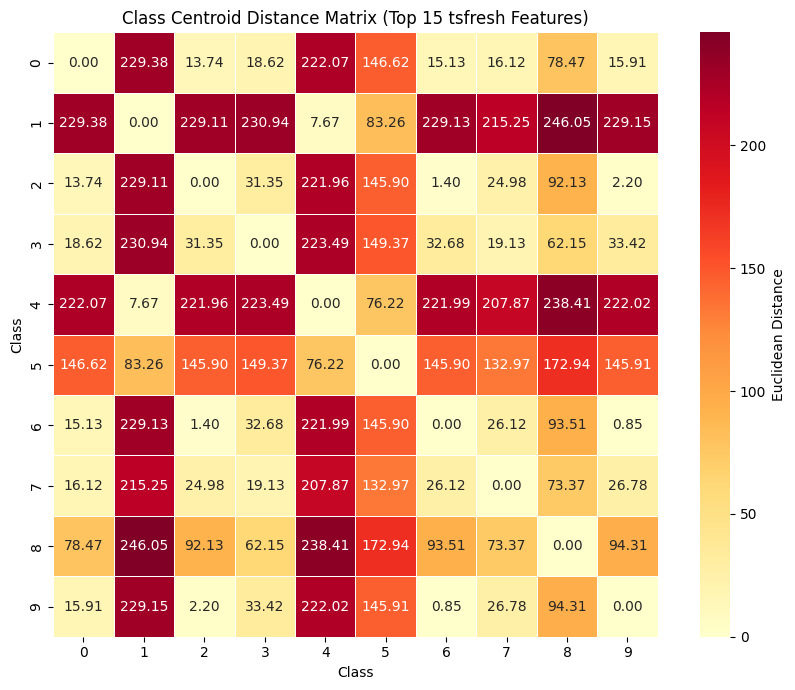

In [13]:
# Top 15 features from tsfresh selection
top15 = X_selected.columns[:15]
df_top15 = X_selected[top15].copy()
df_top15.insert(0, 'label', y)

# Centroids
centroids = df_top15.groupby('label')[top15].mean()

# Euclidean distance matrix
dist_matrix = squareform(pdist(centroids.values, metric='euclidean'))
dist_df = pd.DataFrame(dist_matrix, index=range(10), columns=range(10))

plt.figure(figsize=(9, 7))
sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='YlOrRd', square=True,
            linewidths=0.5, cbar_kws={'label': 'Euclidean Distance'})
plt.title('Class Centroid Distance Matrix (Top 15 tsfresh Features)')
plt.xlabel('Class')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

#### Random Forest Using Top 20 features:

In [ ]:
from sklearn.ensemble import RandomForestClassifier


top_k = 20
selected = X_selected.columns[:top_k]
df_rf = X_selected[selected].copy()
df_rf.insert(0, 'label', y)

X = df_rf[selected].values
y_rf = df_rf['label'].values

# Stratified split: keep exactly 7 per class for training
X_train, X_test, y_train, y_test = train_test_split(
    X, y_rf, train_size=70, stratify=y_rf, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f'Top {top_k} features | Train size: {len(y_train)}  |  Test size: {len(y_test)}')
print(f'\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))


NameError: name 'train_test_split' is not defined

#### this code will help the tester to test on unseen data

In [15]:
import numpy as np
from scipy.fft import fft
from scipy.signal import welch, find_peaks

def ratio_beyond_r_sigma(x, r):
    """Ratio of values that lie more than r * std dev from the mean."""
    return np.sum(np.abs(x - np.mean(x)) > r * np.std(x, ddof=0)) / len(x)

def large_standard_deviation(x, r):
    """Returns 1 if std(x) > r * (max(x) - min(x)), else 0."""
    return 1 if np.std(x, ddof=0) > r * (np.max(x) - np.min(x)) else 0

def number_crossing_m(x, m):
    """Number of crossings of horizontal line y = m."""
    shifted = x - m
    return np.sum(np.diff(np.signbit(shifted)).astype(bool))

def symmetry_looking(x, r):
    """Compares distribution symmetry at fraction r of the value range."""
    split = np.min(x) + r * (np.max(x) - np.min(x))
    left = x[x <= split]
    right = x[x > split]
    if len(left) == 0 or len(right) == 0:
        return 0
    epsilon = 0.05 * (np.max(x) - np.min(x))
    return 1 if np.abs(np.mean(left) - np.mean(right)) < epsilon else 0

def c3_stat(x, lag):
    """Third-order cumulant / nonlinearity statistic at given lag."""
    n = len(x)
    x1 = x[:n - 2*lag]
    x2 = x[lag:n - lag]
    x3 = x[2*lag:]
    return np.mean(x1 * x2 * x3)

def change_quantiles_var(x, ql, qh, is_abs):
    """Variance of successive changes, filtered to quantile corridor."""
    lo, hi = np.quantile(x, [ql, qh])
    mask = (x >= lo) & (x <= hi)
    changes = np.diff(x[mask]) if mask.sum() > 1 else np.array([0])
    if is_abs:
        changes = np.abs(changes)
    return np.var(changes, ddof=0)

def extract_top20_features(df_csv):
    """Given a raw DataFrame (label + 1460 cols), returns (N, 21) top-20 features DF."""
    feature_cols = list(range(1, 1461))
    X_raw = df_csv[feature_cols].values
    feats = np.column_stack([
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 7),
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 5),
        np.apply_along_axis(lambda x: len(find_peaks(x)[0]), 1, X_raw),
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 6),
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 3),
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 2.5),
        np.apply_along_axis(ratio_beyond_r_sigma, 1, X_raw, 2),
        np.apply_along_axis(large_standard_deviation, 1, X_raw, 0.2),
        np.apply_along_axis(number_crossing_m, 1, X_raw, -1),
        np.apply_along_axis(large_standard_deviation, 1, X_raw, 0.25),
        np.apply_along_axis(symmetry_looking, 1, X_raw, 0.1),
        np.apply_along_axis(large_standard_deviation, 1, X_raw, 0.3),
        np.apply_along_axis(lambda x: np.abs(fft(x)[17]), 1, X_raw),
        np.apply_along_axis(lambda x: np.abs(fft(x)[10]), 1, X_raw),
        np.apply_along_axis(lambda x: welch(x, nperseg=min(256, len(x)))[1][2], 1, X_raw),
        np.apply_along_axis(c3_stat, 1, X_raw, 3),
        np.apply_along_axis(c3_stat, 1, X_raw, 1),
        np.apply_along_axis(lambda x: np.max(
            [np.polyfit(np.arange(min(50, len(x[i:i+50]))), x[i:i+50], 1)[1]
             for i in range(0, len(x)-50, 50)] or [0]
        ), 1, X_raw),
        np.apply_along_axis(change_quantiles_var, 1, X_raw, 0.0, 0.8, False),
        np.apply_along_axis(lambda x: np.abs(fft(x)[6]), 1, X_raw),
    ])
    df = pd.DataFrame(feats, columns=top20_cols)
    df.insert(0, 'label', df_csv['label'].values)
    return df

top20_cols = [
    'ratio_beyond_r_sigma__r_7', 'ratio_beyond_r_sigma__r_5',
    'number_peaks__n_3', 'ratio_beyond_r_sigma__r_6',
    'ratio_beyond_r_sigma__r_3', 'ratio_beyond_r_sigma__r_2.5',
    'ratio_beyond_r_sigma__r_2', 'large_std__r_0.2',
    'number_crossing_m__m_-1', 'large_std__r_0.25',
    'symmetry_looking__r_0.1', 'large_std__r_0.3',
    'fft_abs__coeff_17', 'fft_abs__coeff_10',
    'spkt_welch__coeff_2', 'c3__lag_3', 'c3__lag_1',
    'linear_trend_intercept_max__chunk_50',
    'change_quantiles_var__ql0.0_qh0.8',
    'fft_abs__coeff_6',
]

#### this is for the testing with actuall data

In [ ]:
df_val = pd.read_csv('', header=None) # insert the test.csv 
df_val.rename(columns={0: 'label'}, inplace=True)
df_val_top20 = extract_top20_features(df_val)

# Predict with trained RF

X_val = df_val_top20[top20_cols].values
y_val_pred = rf.predict(X_val)
y_val_true = df_val['label'].values
print(f'Accuracy: {accuracy_score(y_val_true, y_val_pred):.4f}')
print(classification_report(y_val_true, y_val_pred))

### Conclusion:
    - The Model Is significantaly better than random guessing (accuracy 10% for 10 classes)
    - 56% may seem low but there is only 3 testing cases per class

## Second Approach

## ROCKET

#TODO: add explanation later

In [48]:
from rocket_functions import generate_kernels, apply_kernels
from sklearn.linear_model import RidgeClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Prepare data
feature_cols = list(range(1, 1461))
X = df_train[feature_cols].values.astype(np.float64)
y = df_train['label'].values

# 60/40 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=60, stratify=y, random_state=42
)

# Generate kernels
kernels = generate_kernels(X_train.shape[-1], 15000)

# Transform
X_train_t = apply_kernels(X_train, kernels)
X_test_t  = apply_kernels(X_test, kernels)

# Fix -inf from ROCKET max features
X_train_t = np.where(np.isfinite(X_train_t), X_train_t, 0.0)
X_test_t  = np.where(np.isfinite(X_test_t), X_test_t, 0.0)

# Train (no scaler needed — PPV is already 0-1, no normalize param)
classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_t, y_train)

# Predict
y_pred = classifier.predict(X_test_t)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.7750
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.80      1.00      0.89         4
           2       0.67      0.50      0.57         4
           3       0.67      0.50      0.57         4
           4       0.67      0.50      0.57         4
           5       0.50      0.50      0.50         4
           6       1.00      1.00      1.00         4
           7       0.80      1.00      0.89         4
           8       0.60      0.75      0.67         4
           9       1.00      1.00      1.00         4

    accuracy                           0.78        40
   macro avg       0.77      0.78      0.77        40
weighted avg       0.77      0.78      0.77        40



In [49]:
# Retrain on ALL 100 samples before validation
X_full = df_train[feature_cols].values.astype(np.float64)
y_full = df_train['label'].values
kernels_full = generate_kernels(X_full.shape[-1], 15000)
X_full_t = apply_kernels(X_full, kernels_full)
X_full_t = np.where(np.isfinite(X_full_t), X_full_t, 0.0)
classifier_full = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier_full.fit(X_full_t, y_full)
print('Trained on all 100 examples.')

Trained on all 100 examples.


In [50]:
df_val = pd.read_csv('../data/validation.csv', header=None)
df_val.rename(columns={0: 'label'}, inplace=True)
X_val = df_val[feature_cols].values.astype(np.float64)
y_val_true = df_val['label'].values
# Transform with SAME kernels, clean inifnities, predict
X_val_t = apply_kernels(X_val, kernels)
X_val_t = np.where(np.isfinite(X_val_t), X_val_t, 0.0)
y_val_pred = classifier.predict(X_val_t)
print(f'Validation Accuracy: {accuracy_score(y_val_true, y_val_pred):.4f}')
print(classification_report(y_val_true, y_val_pred))

Validation Accuracy: 0.8300
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.67      0.80      0.73        10
           3       0.89      0.80      0.84        10
           4       0.88      0.70      0.78        10
           5       1.00      0.50      0.67        10
           6       0.89      0.80      0.84        10
           7       0.75      0.90      0.82        10
           8       0.82      0.90      0.86        10
           9       0.77      1.00      0.87        10

    accuracy                           0.83       100
   macro avg       0.85      0.83      0.83       100
weighted avg       0.85      0.83      0.83       100

